<a href="https://colab.research.google.com/github/shahabday/Deeplearning_challenge_erum_seasnot/blob/main/01_pytorch_dataloader_with_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown

import gdown

url = "https://drive.google.com/file/d/1rD1GVJntPtyukfKNLt764sN13sSSwvel/view?usp=drive_link"

gdown.download(url, quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel
From (redirected): https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel&confirm=t&uuid=8514c087-7971-4a10-9d82-c139fb49e547
To: /content/savetheoceans.nc
100%|██████████| 7.75G/7.75G [01:13<00:00, 106MB/s]


'savetheoceans.nc'

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

In [3]:
data = xr.open_dataset("savetheoceans.nc")

In [11]:
data

<xarray.Dataset> Size: 8GB
Dimensions:  (sample: 2803, channel: 12, x: 240, y: 240)
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 288B '442nm' '492nm' '559nm' ... '2186nm' 'labels'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
Data variables:
    data     (sample, channel, x, y) float32 8GB ...

In [6]:
sample = data["data"].sel(sample = 3 )

In [ ]:
import matplotlib.pyplot as plt


In [37]:
data.isel(sample=0, channel=0)

<xarray.Dataset> Size: 231kB
Dimensions:  (x: 240, y: 240)
Coordinates:
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
    sample   int16 2B 0
    channel  <U6 24B '442nm'
Data variables:
    data     (x, y) float32 230kB ...

In [43]:
da = data["data"]

In [44]:
img = da.isel(sample=0, channel=0)

print("data dtype:", da.dtype)
print("img dtype:", img.dtype)
print("img shape:", img.shape)
print("values dtype:", img.values.dtype)
print("element type:", type(img.values[0,0]))
print("element value:", img.values[0,0])

data dtype: float32
img dtype: float32
img shape: (240, 240)
values dtype: float32
element type: <class 'numpy.float32'>
element value: 0.06999265


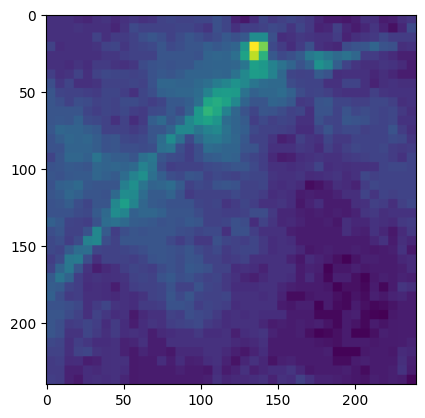

In [46]:
plt.imshow(img)

# Data Loader Pytorch

In [47]:
da = data["data"]

image_channels = [ch for ch in da.coords["channel"].values if ch != "labels"]

X_da = da.sel(channel=image_channels)
Y_da = da.sel(channel="labels")

In [48]:
X_da

<xarray.DataArray 'data' (sample: 2803, channel: 11, x: 240, y: 240)> Size: 7GB
[1775980800 values with dtype=float32]
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 264B '442nm' '492nm' '559nm' ... '1610nm' '2186nm'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239

In [49]:
print(X_da.shape)
print(Y_da.shape)
print(X_da.dims)
print(Y_da.dims)

(2803, 11, 240, 240)
(2803, 240, 240)
('sample', 'channel', 'x', 'y')
('sample', 'x', 'y')


In [55]:
import numpy as np
import torch
from torch.utils.data import Dataset


class XarraySegmentationDataset(Dataset):
    """
    PyTorch Dataset for segmentation from an xarray.DataArray.

    Expected dims:
        (sample, channel, x, y)

    Convention:
        - all channels except `label_channel` are model inputs
        - `label_channel` is the segmentation mask target
        - normalization is applied only to the input channels
    """

    def __init__(
        self,
        da,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
    ):
        self.da = da
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        required_dims = {"sample", "channel", "x", "y"}
        missing_dims = required_dims - set(self.da.dims)
        if missing_dims:
            raise ValueError(f"Missing required dimensions: {missing_dims}")

        if "channel" not in self.da.coords:
            raise ValueError("DataArray must have 'channel' coordinates.")

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(
                f"Label channel '{self.label_channel}' not found in channels: {self.channel_names}"
            )

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        if len(self.input_channels) == 0:
            raise ValueError("No input channels found after excluding label channel.")

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        """
        Normalize each input channel independently.

        Parameters
        ----------
        x : np.ndarray
            Shape (C, H, W)

        Returns
        -------
        np.ndarray
            Shape (C, H, W), normalized channel-wise
        """
        mean = x.mean(axis=(1, 2), keepdims=True)   # (C, 1, 1)
        std = x.std(axis=(1, 2), keepdims=True)     # (C, 1, 1)
        return (x - mean) / (std + self.epsilon)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        # Inputs: all channels except labels
        x = sample.sel(channel=self.input_channels).values.astype(np.float32)   # (C, H, W)

        # Target: labels only
        y = sample.sel(channel=self.label_channel).values                       # (H, W)

        if self.normalize:
            x = self._normalize_per_channel(x)

        # Conventional segmentation target handling:
        # convert labels to integer class indices
        y = np.asarray(y, dtype=np.int64)

        x = torch.from_numpy(x)   # float32
        y = torch.from_numpy(y)   # int64

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

In [56]:
da = data["data"]

dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

x, y = dataset[0]

print("x shape:", x.shape)   # [C, H, W]
print("y shape:", y.shape)   # [H, W]
print("x dtype:", x.dtype)   # torch.float32
print("y dtype:", y.dtype)   # torch.int64

x shape: torch.Size([11, 240, 240])
y shape: torch.Size([240, 240])
x dtype: torch.float32
y dtype: torch.int64


In [57]:
print(dataset.input_channels)

[np.str_('442nm'), np.str_('492nm'), np.str_('559nm'), np.str_('665nm'), np.str_('704nm'), np.str_('739nm'), np.str_('780nm'), np.str_('833nm'), np.str_('864nm'), np.str_('1610nm'), np.str_('2186nm')]


In [58]:
import numpy as np

label_values = np.unique(da.sel(channel="labels").values)
print(label_values)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


In [60]:
from torch.utils.data import random_split, DataLoader

dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [61]:
train_loader